# Classic Jablonski model

In [2]:
import sys
sys.path.append(r"C:\Users\vie43sq\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import numpy as np
import matplotlib.pyplot as plt
import src.fluorophore_systems as fs
import src.custom_plot as cp
import src.large_scale as ls
import src.figures as fi
from IPython.display import HTML

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Define the state transition rates

In [159]:
rate_dict = dict(k_S0_S1=1e15,  # excitation (certainty: high)
                 k_S1_S0=1e8,  # emission (certainty: high)
                 k_S1_T1=1e6,  # intersystem crossing (certainty: middle) 
                 k_T1_S0=1e5,  # phosphorescence (certainty: middle)
                 k_S1_B=1e3,  # bleaching (certainty: low)
                 k_T1_R=1e4,  # reduction (certainty: low)
                 k_R_S0=0.5e0)  # oxidation (certainty: low)

### Initialize system

In [160]:
system = fs.JablonskiModel(number=2, distances=1, rates=rate_dict)

### Simulate the Markov process

In [161]:
time_series, time_step_series, state_series = system.simulate(n_steps=1000000, seed=99, base="cy")

### Receive emission events

In [162]:
emitting_mask, pandas_series, on_periods, off_periods = system.emitters(unit="s", resample="5ms", 
                                                                        photon_collection=0.01)

### Unique states and their occupation times
Example: S0_S1 and S1_S0 are united

In [46]:
unique_series_converted, unique_states, occupation_time_mean = system.process()

### Fluoresecence correlation (Autocorrelation)

In [69]:
auto_correlation = system.fcs()

## Visualization

In [7]:
system.animate(index_range=100, saveas="classic_jablonski.mp4")

In [10]:
HTML("""
<div align="middle">
<video width="80%" controls>
      <source src="jablonski.mp4" type="video/mp4">
</video></div>""")

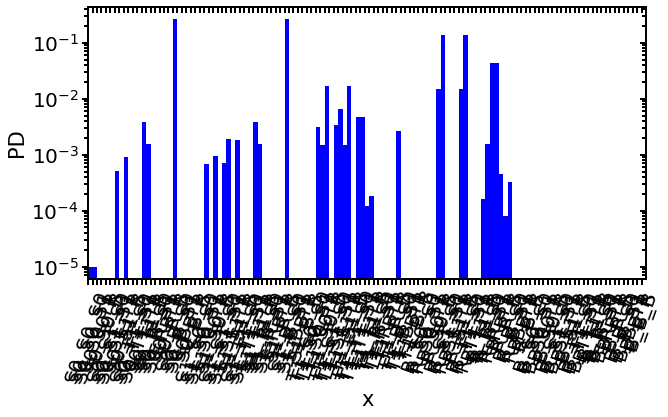

In [51]:
fig, ax = fi.FigureCollection(system).state_population(use_unique=False)

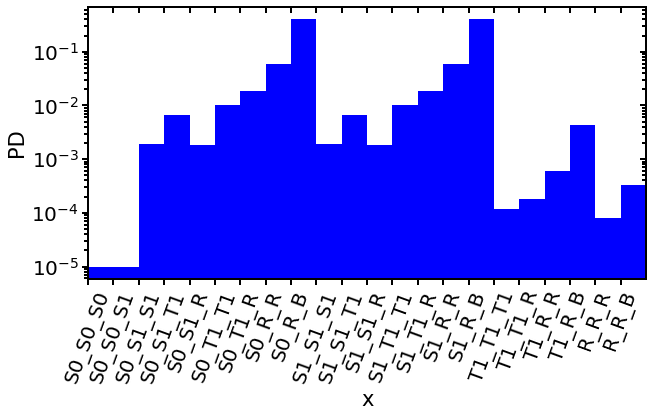

In [50]:
fig, ax = fi.FigureCollection(system).state_population()

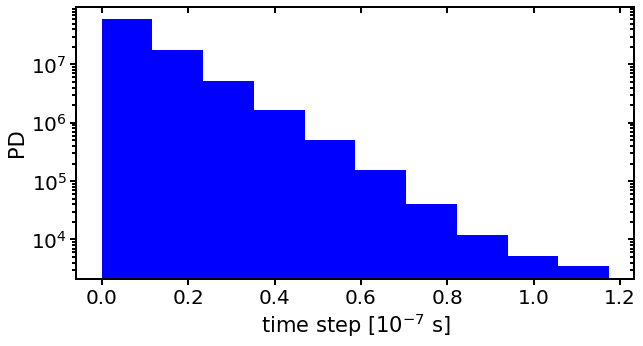

In [54]:
fig, ax = fi.FigureCollection(system).time_steps(xlabel="time step [$10^{-7}$ s]", tick_style_x="sci")

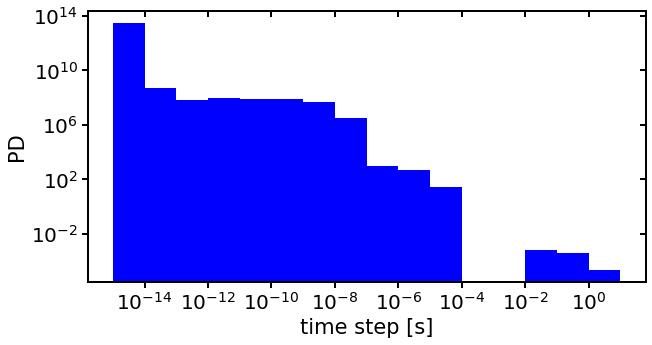

In [58]:
fig, ax = fi.FigureCollection(system).time_steps(only_emitting_transitions=False, 
                                                 xlabel="time step [s]", xscale="log",
                                                 bins=10**(np.arange(-15, 2, dtype=np.float64)))

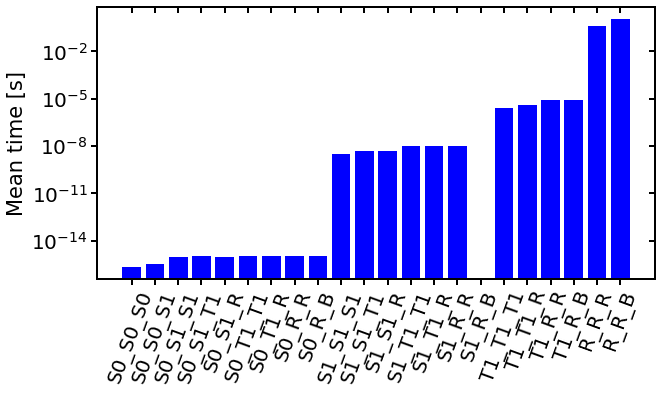

In [60]:
fig, ax = fi.FigureCollection(system).occupation_time()

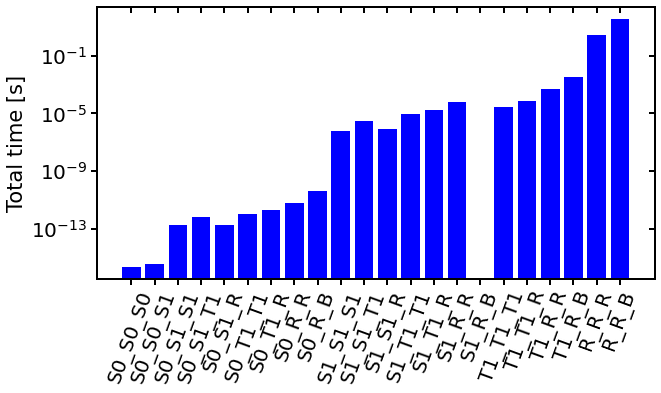

In [61]:
fig, ax = fi.FigureCollection(system).occupation_time(total=True)

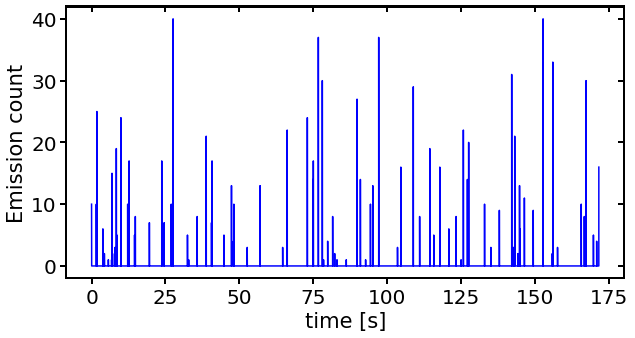

In [205]:
fig, ax = fi.FigureCollection(system).emission_events()

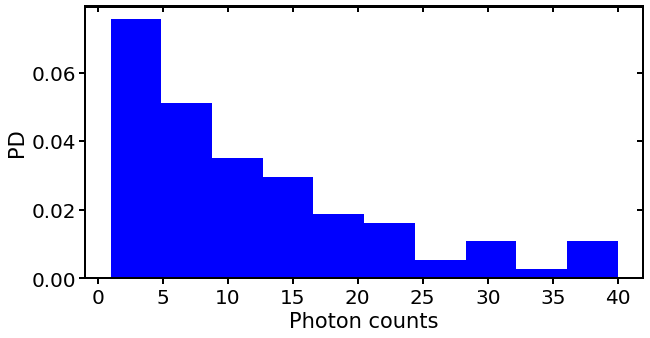

In [206]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False)

In [128]:
auto_correlation = system.fcs(log=False)

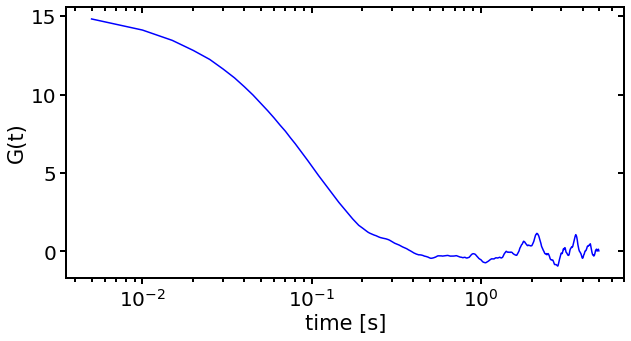

In [129]:
fig, ax = fi.FigureCollection(system).fcs(log=False)

In [130]:
auto_correlation = system.fcs()

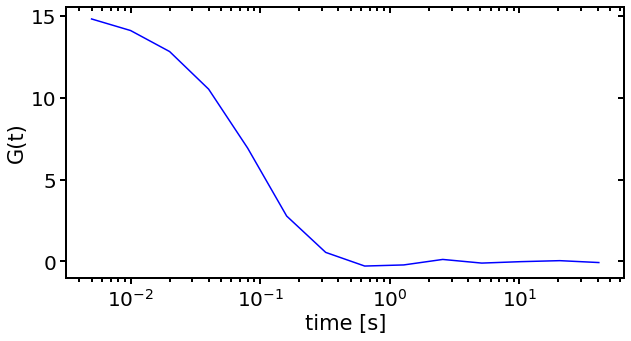

In [131]:
fig, ax = fi.FigureCollection(system).fcs()

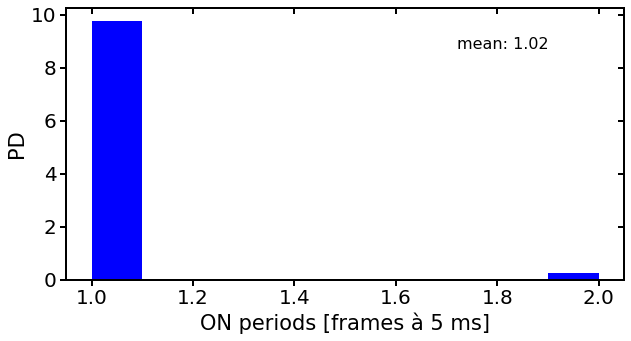

In [119]:
fig, ax = fi.FigureCollection(system).on_off()

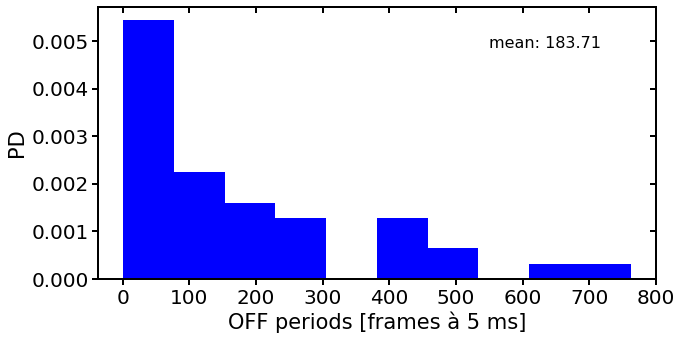

In [121]:
fig, ax = fi.FigureCollection(system).on_off(on=False)

## Multiple runs

In [180]:
class_args = dict(number=3, distances=1, rates=rate_dict)
simulate_args = dict(n_steps=100000, base="cy")
emitting_args = dict(unit="s", resample="5ms")

In [181]:
%%time
systems = ls.multiple_simulations(10, "Jablonski", class_args, simulate_args, emitting_args, 100)

CPU times: total: 23.2 s
Wall time: 23.2 s


In [203]:
data = [[system.pandas_series.index, system.pandas_series.values] for system in systems]

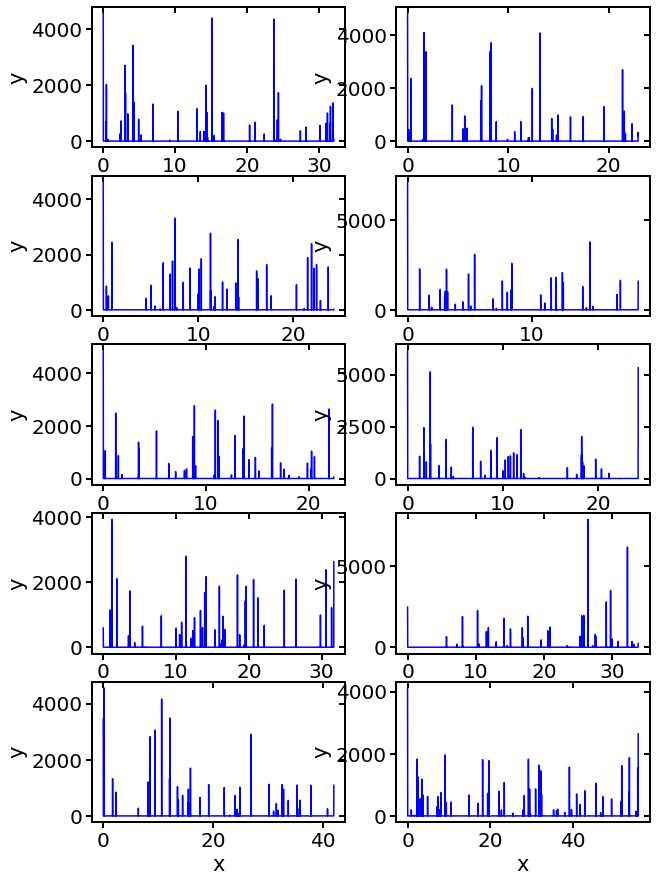

In [204]:
fig, ax = cp.universal_figure(nrows=-(len(systems)//-2), ncols=2, width=10, 
                              height=-(len(systems)//-2)*3, type_="line", data=data)